## Análisis exploratorio de datos (EDA) - Descripción general y análisis univariable

### Proyecto:
Pacientes con problemas de hígado - India

**Autor:** Mariana Bedoya Arismendy

### Fecha:
2026-08-18

### Descripción:

En este notebook caracterizamos el dataset de forma general y estudiamos cada variable por separado (análisis univariable). El objetivo es entender cómo están estructurados los datos, qué problemas de calidad tienen (nulos, duplicados, valores extremos) y cómo se distribuye cada atributo antes de estudiar relaciones entre variables.

El recorrido sigue el orden habitual de un análisis exploratorio: primero cargamos los datos y revisamos su descripción general, luego estudiamos la variable objetivo, después analizamos una por una las variables numéricas y las categóricas, y cerramos con las conclusiones.

## 📚 Importar librerías

Importamos las librerías que usaremos: `pandas` para manipular los datos, `matplotlib` y `seaborn` para los gráficos y `numpy` para algún cálculo auxiliar.

In [ ]:
# Configuración del entorno gráfico para evitar problemas con Tkinter
import matplotlib

matplotlib.use("Agg")

# librerías base para ciencia de datos
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


Configuramos pandas para mostrar solo dos decimales (los valores clínicos no necesitan más precisión en pantalla) y definimos un estilo visual común para todos los gráficos del notebook.

In [ ]:
# configuración para mostrar solo 2 decimales
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid")

Imprimimos las versiones de las librerías para que el análisis sea reproducible: si alguien ejecuta este notebook más adelante con otras versiones y los resultados difieren, esta es la primera pista para investigar la causa.

In [ ]:
# imprimir versiones de las librerías para reproducibilidad
print("Versión de Python: ", sys.version)
print("Versión de pandas: ", pd.__version__)
print("Versión de seaborn: ", sns.__version__)

Versión de Python:  3.12.11 (main, Jul  1 2025, 05:29:09) [GCC 12.2.0]
Versión de pandas:  2.3.3
Versión de seaborn:  0.13.2


## 💾 Cargar datos

Cargamos el mismo archivo Parquet que usamos en el notebook de perfilado. Verificamos que el archivo exista antes de leerlo y comprobamos el tamaño resultante. La ruta es relativa a la raíz del proyecto, así el notebook funciona en cualquier instalación.

In [ ]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"
DATA_PATH = (
    DATA_DIR / "02_intermediate/Pacientes_porblemas_higado_india_type_fixed.parquet"
)

assert DATA_PATH.exists(), f"No se encuentra el archivo del proyecto: {DATA_PATH}"

df = pd.read_parquet(DATA_PATH, engine="pyarrow")

print(f"Dataset cargado: {df.shape[0]} filas y {df.shape[1]} columnas")

Dataset cargado: 663 filas y 11 columnas


## 📊 Descripción de los datos

### Información general

Empezamos con `info()` para ver los tipos de datos de cada columna y cuántos valores no nulos tiene. Es la forma más rápida de confirmar que la estructura coincide con lo que esperamos del proyecto: una tabla de pacientes con pruebas de función hepática, el género y el diagnóstico.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 663 entries, 0 to 662
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Age                         662 non-null    Int64   
 1   Gender                      655 non-null    category
 2   Total_Bilirubin             657 non-null    Float64 
 3   Direct_Bilirubin            656 non-null    Float64 
 4   Alkaline_Phosphotase        646 non-null    Float64 
 5   Alamine_Aminotransferase    644 non-null    Float64 
 6   Aspartate_Aminotransferase  651 non-null    Float64 
 7   Total_Protiens              656 non-null    Float64 
 8   Albumin                     661 non-null    Float64 
 9   Albumin_and_Globulin_Ratio  659 non-null    Float64 
 10  Dataset                     648 non-null    category
dtypes: Float64(8), Int64(1), category(2)
memory usage: 54.1 KB


Lo que observamos:

- Hay **663 registros y 11 columnas**.
- Nueve columnas son numéricas: `Age` es entero y las ocho pruebas clínicas son decimales (los tipos `Int64` y `Float64` son versiones de pandas que admiten nulos sin convertir la columna a `float`).
- Dos columnas son categóricas: `Gender` (género del paciente) y `Dataset` (el target).
- Todas las columnas tienen algún valor nulo, pero en cantidades pequeñas (entre 1 y 19 por columna).

Sobre el significado de las variables: el dataset corresponde a un panel de pruebas de función hepática, un conjunto de análisis de laboratorio estándar que se usa para evaluar el estado del hígado. La interpretación de cada prueba es la habitual en clínica (por ejemplo, la bilirrubina y las transaminasas se elevan cuando hay daño hepático, y la albúmina desciende cuando el hígado no sintetiza bien proteínas). La documentación del dataset no incluye las unidades de medida, así que cualquier referencia a unidades (mg/dL, U/L, g/dL) debe tomarse como una **hipótesis razonable**, no como un dato confirmado.

Este dataset **no contiene** variables booleanas, de texto libre ni de fecha, por lo que esas secciones del análisis no aplican: todas las columnas son numéricas continuas, categóricas o el target.

#### Tamaño y muestra de los datos

Miramos una muestra aleatoria de registros para tener una idea de cómo se ven los datos en la práctica. Usamos una semilla fija para que la muestra sea la misma cada vez que se ejecute el notebook.

In [ ]:
# tamaño del dataframe
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas")

# muestra aleatoria con semilla fija para reproducibilidad
df.sample(5, random_state=42)

El dataset tiene 663 filas y 11 columnas


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
327,24,Male,3.30,1.60,174.00,11.00,33.00,7.60,3.90,1.00,2
579,40,Male,0.60,0.10,98.00,35.00,31.00,6.00,3.20,1.10,1
513,69,NaN,<NA>,<NA>,215.00,32.00,24.00,6.90,3.00,0.70,NaN
362,55,Male,1.10,0.30,215.00,21.00,15.00,6.20,2.90,0.80,2
265,4,Male,0.90,0.20,348.00,30.00,34.00,8.00,4.00,1.00,2


La muestra confirma la estructura: cada fila es un paciente con su edad, género, los resultados de las pruebas hepáticas y la etiqueta del diagnóstico (`Dataset`). Los valores de las pruebas son decimales con un decimal de precisión, la edad es un entero y el género y el target son categorías de texto.

#### Valores nulos

¿Cuántos valores faltantes hay y dónde están? Esta pregunta es importante porque los nulos condicionan el análisis (algunos cálculos los ignoran automáticamente) y porque en un futuro modelo habrá que imputarlos o descartar registros.

Calculamos la cantidad y el porcentaje de nulos por columna, ordenados de mayor a menor.

In [ ]:
nulos = pd.DataFrame(
    {
        "nulos": df.isnull().sum(),
        "porcentaje": (df.isnull().mean() * 100).round(2),
    }
)
nulos = nulos[nulos["nulos"] > 0].sort_values("nulos", ascending=False)
nulos.loc["TOTAL"] = [
    nulos["nulos"].sum(),
    round(df.isnull().to_numpy().mean() * 100, 2),
]
nulos

,nulos,porcentaje
Alamine_Aminotransferase,19.00,2.87
Alkaline_Phosphotase,17.00,2.56
Dataset,15.00,2.26
Aspartate_Aminotransferase,12.00,1.81
Gender,8.00,1.21
Direct_Bilirubin,7.00,1.06
Total_Protiens,7.00,1.06
Total_Bilirubin,6.00,0.90
Albumin_and_Globulin_Ratio,4.00,0.60
Albumin,2.00,0.30


**Resultado:** en total hay 98 celdas con valores faltantes, un 1.34% de la tabla. Ninguna variable tiene un problema grave de nulos: la más afectada es `Alamine_Aminotransferase` con 19 nulos (2.87%) y la menos afectada es `Age` con apenas 1 (0.15%).

Dos observaciones con implicaciones para el proyecto:

1. **El target `Dataset` tiene 15 nulos (2.26%).** Estos registros no tienen etiqueta, así que no servirán para entrenar un modelo supervisado. Habrá que decidir si se descartan o si se les da otro tratamiento en la etapa de preparación de datos.
2. **Los nulos están repartidos en todas las columnas.** Como cada variable falla en pacientes distintos, la combinación de nulos puede afectar a más filas de lo que sugiere el 1.34% global. El impacto exacto se evaluará cuando se defina la estrategia de imputación.

Para el análisis univariable que sigue, los estadísticos y gráficos se calculan ignorando los nulos de cada variable (que es el comportamiento estándar de pandas).

#### Filas duplicadas

¿Hay registros duplicados? Es una pregunta relevante por dos motivos: los duplicados pueden inflar artificialmente la importancia de ciertos patrones en un futuro modelo, y pueden indicar problemas en la recolección de datos.

In [ ]:
n_duplicados = df.duplicated().sum()
p_duplicados = df.duplicated().mean() * 100

print(f"Filas duplicadas: {n_duplicados} de {len(df)} ({p_duplicados:.1f}%)")

# filas involucradas en duplicados (incluyendo la primera aparición de cada grupo)
involucradas = df.duplicated(keep=False).sum()
grupos = df[df.duplicated(keep=False)].drop_duplicates().shape[0]
print(f"Filas involucradas en grupos de duplicados: {involucradas}")
print(f"Grupos distintos de valores repetidos: {grupos}")

Filas duplicadas: 60 de 663 (9.0%)
Filas involucradas en grupos de duplicados: 111
Grupos distintos de valores repetidos: 51


**Resultado:** hay 60 filas duplicadas (9.0% del dataset). En total, 111 filas forman parte de 51 grupos de valores repetidos: la mayoría de los grupos son pares, pero hay algunos con 3 y hasta 4 repeticiones idénticas.

**Interpretación:** el dataset no tiene una columna de identificación de paciente, así que no podemos distinguir entre dos explicaciones: (a) el mismo paciente fue registrado varias veces, o (b) pacientes distintos que coincidieron en todas las pruebas clínicas y en el diagnóstico. La segunda opción no es descabellada en un panel hepático, donde varios valores son discretos y muchos pacientes tienen resultados "normales" parecidos.

**Implicación:** en esta etapa de EDA no eliminamos nada (eliminar duplicados es una decisión de preparación de datos). Lo que sí queda documentado es que, si se decidiera conservarlos, un futuro modelo vería esos patrones reforzados artificialmente; y si se eliminaran, el dataset se reduciría a unas 603 filas. La recomendación es evaluar ambas opciones en la etapa de modelado usando validación con datos no vistos.

#### Cardinalidad y valores únicos

¿Cuántos valores distintos toma cada variable? Esta pregunta nos permite detectar columnas constantes, identificadores encubiertos o variables que en realidad se comportan como categóricas.

In [ ]:
cardinalidad = pd.DataFrame(
    {
        "valores_unicos": df.nunique(),
        "tipo": df.dtypes.astype(str),
    }
)
cardinalidad

,valores_unicos,tipo
Age,72,Int64
Gender,2,category
Total_Bilirubin,113,Float64
Direct_Bilirubin,80,Float64
Alkaline_Phosphotase,262,Float64
Alamine_Aminotransferase,152,Float64
Aspartate_Aminotransferase,176,Float64
Total_Protiens,58,Float64
Albumin,40,Float64
Albumin_and_Globulin_Ratio,69,Float64


**Resultado:** ninguna columna es constante ni funciona como identificador (ninguna tiene 663 valores únicos). `Gender` y `Dataset` tienen exactamente 2 categorías, como corresponde. `Age` tiene 72 valores distintos (edades de 4 a 90 años) y las pruebas clínicas tienen entre 40 y 262 valores distintos, coherente con medidas de laboratorio con un decimal de precisión.

**Interpretación:** todas las variables tienen potencial informativo; no hay columnas para descartar por cardinalidad. Tampoco hay riesgo aparente de fuga de información: ninguna variable parece derivarse del target ni contener información del futuro.

#### Consistencia entre variables

Además de analizar cada variable por separado, conviene comprobar que las variables sean coherentes **entre sí**. Existe una restricción fisiológica evidente en este dataset: la bilirrubina directa es una fracción de la bilirrubina total (es la parte que el hígado ya conjugó), así que **ningún paciente debería tener una bilirrubina directa mayor que su bilirrubina total**. Si encontramos casos así, serían valores imposibles desde el punto de vista clínico: errores de captura, de transcripción o de unidades, y no simples valores extremos.

In [ ]:
# filas que violan la restricción fisiológica Direct_Bilirubin <= Total_Bilirubin
inconsistente = df[df["Direct_Bilirubin"] > df["Total_Bilirubin"]]
print(
    f"Filas con Direct_Bilirubin > Total_Bilirubin: {len(inconsistente)} de {len(df)}"
)
inconsistente[["Age", "Gender", "Total_Bilirubin", "Direct_Bilirubin", "Dataset"]]

Filas con Direct_Bilirubin > Total_Bilirubin: 3 de 663


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Dataset
246,55,Male,1.80,9.00,1
261,33,Male,1.50,7.00,1
279,48,Female,1.00,1.40,1


**Resultado:** hay **3 filas** que violan la restricción (índices 246, 261 y 279). En dos de ellas la violación es flagrante: un paciente con bilirrubina total de 1.8 y directa de 9.0, y otro con total de 1.5 y directa de 7.0. La tercera es más sutil (total 1.0, directa 1.4). Las tres pertenecen a la clase `1` (problemas de hígado).

**Interpretación:** estos sí son candidatos claros a **valores incorrectos**, no a valores extremos: la bilirrubina directa no puede exceder a la total en ningún escenario fisiológico. En los dos casos flagrantes los valores incluso parecen resultado de una transposición de dígitos o de un error de registro (9.0 con 1.8, 7.0 con 1.5). Sin acceso a la fuente original no podemos corregirlos ni confirmar cuál de las dos columnas está mal.

**Implicación para el proyecto:** en esta etapa de EDA no los eliminamos ni corregimos (eso es preparación de datos), pero quedan identificados. Para el futuro modelo habrá que decidir cómo tratarlos: corregir si se consigue la fuente, descartar las 3 filas, o al menos ser consciente de que contaminan especialmente a la clase enferma y a cualquier análisis que use ambas bilirrubinas a la vez. Esta comprobación queda además como regla de validación formal en el notebook 04.

#### Estadísticas generales del conjunto de datos

##### Variables numéricas

Generamos las estadísticas descriptivas de todas las variables numéricas. Comparar la media con la mediana de cada variable nos da una primera idea de la asimetría: si la media está muy por encima de la mediana, hay una cola derecha (valores extremos altos).

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,662.00,44.82,16.18,4.00,33.00,45.00,57.00,90.00
Total_Bilirubin,657.00,3.38,6.28,0.40,0.80,1.00,2.70,75.00
Direct_Bilirubin,656.00,1.53,2.88,0.10,0.20,0.30,1.30,19.70
Alkaline_Phosphotase,646.00,285.31,233.44,63.00,175.00,208.00,291.50,2110.00
Alamine_Aminotransferase,644.00,80.79,185.49,10.00,23.00,35.00,60.00,2000.00
Aspartate_Aminotransferase,651.00,110.96,278.32,10.00,26.00,43.00,90.00,4929.00
Total_Protiens,656.00,6.47,1.07,2.70,5.80,6.50,7.20,9.60
Albumin,661.00,3.12,0.79,0.90,2.60,3.10,3.70,5.50
Albumin_and_Globulin_Ratio,659.00,0.94,0.32,0.30,0.70,0.93,1.10,2.80


**Observación general:** en `Age`, `Total_Protiens`, `Albumin` y `Albumin_and_Globulin_Ratio` la media y la mediana son casi iguales, lo que sugiere distribuciones más o menos simétricas. En cambio, en las cinco pruebas hepáticas (`Total_Bilirubin`, `Direct_Bilirubin`, `Alkaline_Phosphotase`, `Alamine_Aminotransferase`, `Aspartate_Aminotransferase`) la media supera con claridad a la mediana: por ejemplo, `Aspartate_Aminotransferase` tiene media 111 frente a mediana 43. Esto indica fuertes colas derechas con valores extremos, algo que confirmamos variable por variable más abajo.

##### Variables categóricas

Describimos también las variables categóricas: cuántas categorías tienen, cuál es la más frecuente (la moda) y cuántos valores no nulos contiene cada una.

In [ ]:
# descripción de las columnas categóricas
df.describe(include="category").T

,count,unique,top,freq
Gender,655,2,Male,499
Dataset,648,2,1,460


**Resultado:** `Gender` tiene 2 categorías y su moda es `Male` (presente en la gran mayoría de los registros); `Dataset` tiene 2 categorías y su moda es `1` (problemas de hígado). El análisis detallado de ambas variables está más abajo, en la sección de análisis univariable.

### 📈 Análisis univariable

Ahora estudiamos cada variable por separado. Para las numéricas seguimos siempre el mismo guión: estadísticos descriptivos completos (incluyendo asimetría y curtosis), número de valores únicos y tres gráficos (histograma, densidad y diagrama de cajas). Para las categóricas: frecuencias absolutas y relativas, moda y gráfico de barras.

Empezamos por la variable objetivo, porque es la que queremos predecir y su comportamiento condiciona todo el proyecto.

#### Variable objetivo (Dataset)

**¿Qué vamos a analizar?** La distribución de la variable `Dataset`, que indica el diagnóstico: `1` significa que el paciente tiene problemas de hígado y `2` que no los tiene. Esta interpretación proviene de la documentación del proyecto y de los notebooks de las etapas anteriores.

**¿Por qué lo analizamos?** Porque en un proyecto de aprendizaje supervisado el primer paso es saber qué se va a predecir y cómo están repartidas las clases. Si las clases están desbalanceadas, las métricas habituales (como el accuracy) dejan de ser confiables y hay que planear estrategias específicas.

Una precisión técnica importante: aunque los valores del target son `1` y `2`, están almacenados como **texto** (categorías `'1'` y `'2'`), no como números. Hay que respetar ese tipo al comparar valores, por ejemplo usando `== "1"` y no `== 1`.

In [ ]:
target_info = pd.DataFrame(
    {
        "cantidad": df["Dataset"].value_counts(dropna=False),
        "porcentaje": (
            df["Dataset"].value_counts(dropna=False, normalize=True) * 100
        ).round(2),
    }
)
target_info

,cantidad,porcentaje
Dataset,,
1,460,69.38
2,188,28.36
NaN,15,2.26


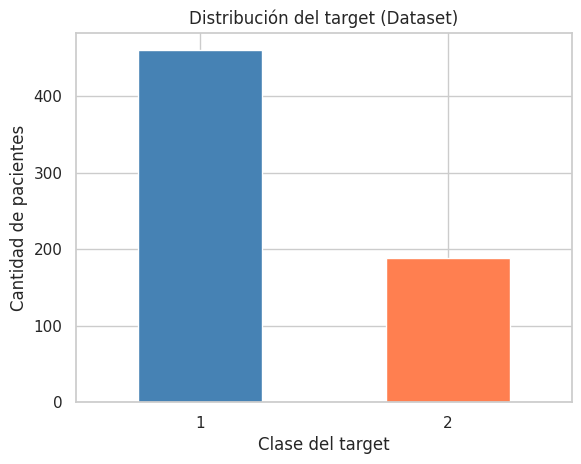

In [ ]:
df["Dataset"].value_counts().plot(
    kind="bar", color=["steelblue", "coral"], title="Distribución del target (Dataset)"
)
plt.xlabel("Clase del target")
plt.ylabel("Cantidad de pacientes")
plt.xticks(rotation=0)
plt.show()

**Resultado:** de los 648 pacientes con etiqueta, 460 (71.0%) pertenecen a la clase `1` (problemas de hígado) y 188 (29.0%) a la clase `2` (sin problemas). Además hay 15 pacientes (2.26%) sin etiqueta.

**Interpretación:** existe un **desbalance moderado**: por cada paciente sano hay unos 2.4 con problemas de hígado. Esto es coherente con el origen del dataset (pacientes atendidos en un entorno clínico con sospecha de patología hepática), pero tiene consecuencias para el futuro modelo:

- Un clasificador trivial que predijera siempre "problemas de hígado" acertaría el 71% de las veces. El accuracy, por sí solo, será una métrica engañosa.
- Habrá que usar métricas por clase (precisión, recall, F1 por clase) o globales sensibles al desbalance (AUC-ROC), y evaluar técnicas de balanceo (ponderación de clases, sobremuestreo o submuestreo).

**Implicación para el proyecto:** confirmamos que el target es `Dataset` y que el problema es una clasificación binaria con desbalance moderado. Los 15 registros sin etiqueta no podrán usarse en el entrenamiento.

#### Variables numéricas

Listamos las columnas numéricas y calculamos una tabla resumen con los estadísticos que pide el análisis univariable: tendencia central (media, mediana, moda), dispersión (desviación, varianza, rango, cuartiles, IQR) y forma (asimetría y curtosis). Después comentamos la tabla y analizamos cada variable con sus gráficos.

In [ ]:
# lista de las columnas numéricas
numerical_columns = list(
    df.select_dtypes(include=["number", "Int64", "Float64"]).columns
)
numerical_columns

['Age',
 'Total_Bilirubin',
 'Direct_Bilirubin',
 'Alkaline_Phosphotase',
 'Alamine_Aminotransferase',
 'Aspartate_Aminotransferase',
 'Total_Protiens',
 'Albumin',
 'Albumin_and_Globulin_Ratio']

##### Tabla resumen de estadísticos

Calculamos la tabla completa para las nueve variables numéricas. La asimetría (*skewness*) mide qué tan cargada está la distribución hacia un lado (positiva = cola derecha) y la curtosis (*kurtosis*) mide qué tan pesadas son las colas respecto a una distribución normal.

In [ ]:
resumen = pd.DataFrame(
    {
        "n": df[numerical_columns].count(),
        "media": df[numerical_columns].mean().round(2),
        "mediana": df[numerical_columns].median(),
        "moda": df[numerical_columns].mode().iloc[0],
        "desv": df[numerical_columns].std().round(2),
        "varianza": df[numerical_columns].var().round(1),
        "min": df[numerical_columns].min(),
        "max": df[numerical_columns].max(),
        "Q1": df[numerical_columns].quantile(0.25),
        "Q3": df[numerical_columns].quantile(0.75),
    }
)
resumen["rango"] = resumen["max"] - resumen["min"]
resumen["IQR"] = resumen["Q3"] - resumen["Q1"]
resumen["asimetria"] = df[numerical_columns].skew().round(2)
resumen["curtosis"] = df[numerical_columns].kurt().round(2)
resumen[
    [
        "n",
        "media",
        "mediana",
        "moda",
        "desv",
        "min",
        "max",
        "rango",
        "Q1",
        "Q3",
        "IQR",
        "asimetria",
        "curtosis",
    ]
]

,n,media,mediana,moda,desv,min,max,rango,Q1,Q3,IQR,asimetria,curtosis
Age,662,44.82,45.00,60.00,16.18,4.00,90.00,86.00,33.00,57.00,24.00,-0.00,-0.51
Total_Bilirubin,657,3.38,1.00,0.80,6.28,0.40,75.00,74.60,0.80,2.70,1.90,4.68,33.54
Direct_Bilirubin,656,1.53,0.30,0.20,2.88,0.10,19.70,19.60,0.20,1.30,1.10,3.20,11.43
Alkaline_Phosphotase,646,285.31,208.00,215.00,233.44,63.00,2110.00,2047.00,175.00,291.50,116.50,3.90,19.31
Alamine_Aminotransferase,644,80.79,35.00,20.00,185.49,10.00,2000.00,1990.00,23.00,60.00,37.00,6.57,50.17
Aspartate_Aminotransferase,651,110.96,43.00,23.00,278.32,10.00,4929.00,4919.00,26.00,90.00,64.00,10.61,156.86
Total_Protiens,656,6.47,6.50,6.00,1.07,2.70,9.60,6.90,5.80,7.20,1.40,-0.24,0.27
Albumin,661,3.12,3.10,3.00,0.79,0.90,5.50,4.60,2.60,3.70,1.10,-0.01,-0.41
Albumin_and_Globulin_Ratio,659,0.94,0.93,1.00,0.32,0.30,2.80,2.50,0.70,1.10,0.40,1.03,3.43


**Lectura de la tabla:**

- **Simétricas** (asimetría entre -0.5 y 0.5): `Age` (-0.00), `Albumin` (-0.01), `Total_Protiens` (-0.24) y casi `Albumin_and_Globulin_Ratio` (1.03, moderada).
- **Fuertemente asimétricas a la derecha**: `Aspartate_Aminotransferase` (10.61), `Alamine_Aminotransferase` (6.57), `Total_Bilirubin` (4.69), `Alkaline_Phosphotase` (3.90) y `Direct_Bilirubin` (3.20). Sus medias quedan muy por encima de sus medianas por culpa de los valores extremos.
- **Curtosis extremas**: `Aspartate_Aminotransferase` (156.9) y `Alamine_Aminotransferase` (50.2) tienen colas muchísimo más pesadas que una normal: unos pocos pacientes concentran valores enormes.

A continuación analizamos cada variable con sus gráficos.

##### Age

**¿Qué analizamos y por qué?** La edad del paciente en años. Nos interesa su distribución para saber qué población representa el dataset y si la edad podría aportar información al futuro modelo.

In [ ]:
column = "Age"

# estadísticos descriptivos y número de valores únicos
display(df[column].describe().to_frame().T)
print(f"Valores únicos: {df[column].nunique()}")
print(
    f"Valores nulos: {df[column].isnull().sum()} ({df[column].isnull().mean() * 100:.2f}%)"
)

,count,mean,std,min,25%,50%,75%,max
Age,662.00,44.82,16.18,4.00,33.00,45.00,57.00,90.00


Valores únicos: 72
Valores nulos: 1 (0.15%)


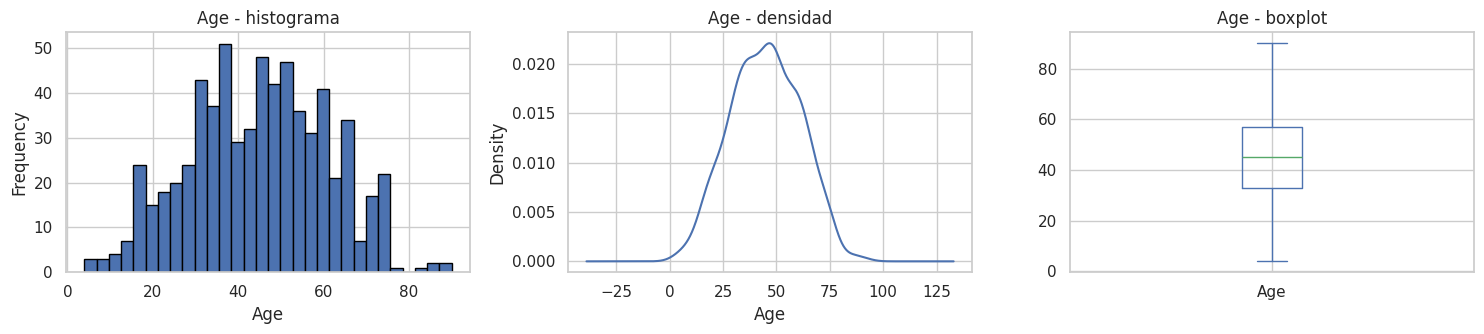

In [ ]:
# histograma, curva de densidad y diagrama de cajas
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

df["Age"].plot(
    kind="hist", bins=30, edgecolor="black", ax=axes[0], title="Age - histograma"
)
df["Age"].plot(kind="density", ax=axes[1], title="Age - densidad")
df["Age"].plot(kind="box", ax=axes[2], title="Age - boxplot")

for ax in axes[:2]:
    ax.set_xlabel("Age")
plt.tight_layout()
plt.show()

**Resultado:** la edad va de 4 a 90 años, con media 44.8 y mediana 45: son prácticamente iguales y la asimetría es -0.00, así que la distribución es simétrica. Solo hay 1 valor nulo (0.15%).

**Interpretación:** el dataset representa sobre todo a adultos (el 50% central está entre 33 y 57 años), pero incluye desde niños pequeños hasta personas de 90 años. No se observan valores imposibles (edades negativas o de más de 120 años) ni valores atípicos que parezcan errores: los extremos son edades perfectamente posibles.

**Implicación:** la edad es una variable limpia y sin problemas de calidad. Su utilidad predictiva parece moderada (los boxplots por clase del notebook 03 mostrarán una diferencia pequeña entre clases), pero no hay motivo para descartarla en esta etapa.

##### Total_Bilirubin

**¿Qué analizamos y por qué?** La bilirrubina total del paciente. Es una de las pruebas hepáticas centrales: la bilirrubina se eleva cuando el hígado no la procesa bien, así que esperamos que sea relevante para el diagnóstico. La hipótesis de unidades es mg/dL, con un rango normal aproximado de 0.1 a 1.2.

In [ ]:
column = "Total_Bilirubin"

# estadísticos descriptivos y número de valores únicos
display(df[column].describe().to_frame().T)
print(f"Valores únicos: {df[column].nunique()}")
print(
    f"Valores nulos: {df[column].isnull().sum()} ({df[column].isnull().mean() * 100:.2f}%)"
)

,count,mean,std,min,25%,50%,75%,max
Total_Bilirubin,657.00,3.38,6.28,0.40,0.80,1.00,2.70,75.00


Valores únicos: 113
Valores nulos: 6 (0.90%)


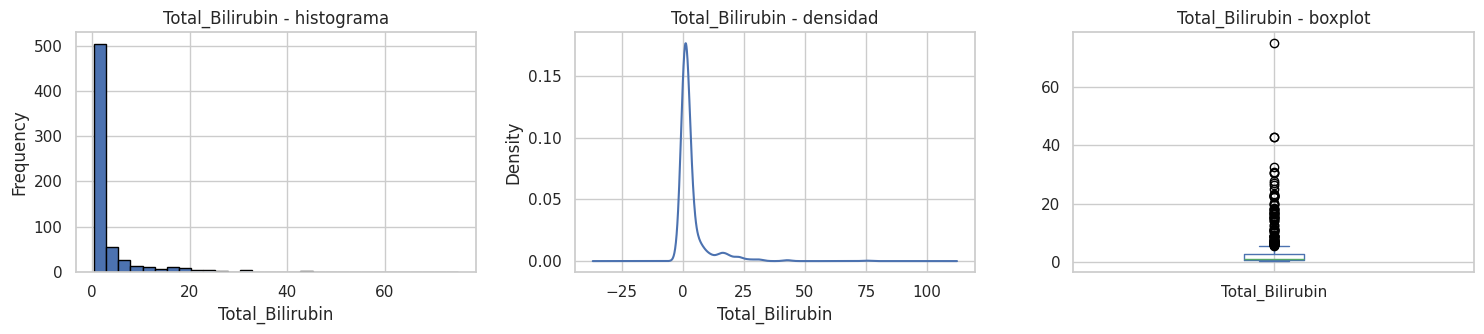

In [ ]:
# histograma, curva de densidad y diagrama de cajas
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

df["Total_Bilirubin"].plot(
    kind="hist",
    bins=30,
    edgecolor="black",
    ax=axes[0],
    title="Total_Bilirubin - histograma",
)
df["Total_Bilirubin"].plot(
    kind="density", ax=axes[1], title="Total_Bilirubin - densidad"
)
df["Total_Bilirubin"].plot(kind="box", ax=axes[2], title="Total_Bilirubin - boxplot")

for ax in axes[:2]:
    ax.set_xlabel("Total_Bilirubin")
plt.tight_layout()
plt.show()

**Resultado:** los valores van de 0.4 a 75.0, con mediana 1.0 y media 3.38. La asimetría es 4.69 y la curtosis 33.5: la gran mayoría de los pacientes está en valores bajos (el 75% por debajo de 2.7), pero hay una cola larga de valores altos. Hay 6 nulos (0.90%).

**Interpretación:** el histograma y el boxplot lo confirman: la distribución está muy concentrada cerca de valores bajos con un pequeño número de pacientes con valores muy elevados (hasta 75, más de 60 veces la mediana). En el contexto clínico, valores altos de bilirrubina son plausibles en pacientes con enfermedad hepática avanzada, así que estos extremos más parecen **valores reales de pacientes graves** que errores de captura.

**Implicación:** no conviene eliminar estos valores por ser "raros"; son justo los casos que mejor caracterizan la enfermedad. Para un futuro modelo, esta asimetría sugiere evaluar una transformación logarítmica (documentada en el notebook 04), y usar estadísticos robustos (mediana, IQR) al describirla.

##### Direct_Bilirubin

**¿Qué analizamos y por qué?** La bilirrubina directa (conjugada), que es la fracción de la bilirrubina total que el hígado ya procesó. Por su origen, esperamos que esté muy relacionada con la bilirrubina total.

In [ ]:
column = "Direct_Bilirubin"

# estadísticos descriptivos y número de valores únicos
display(df[column].describe().to_frame().T)
print(f"Valores únicos: {df[column].nunique()}")
print(
    f"Valores nulos: {df[column].isnull().sum()} ({df[column].isnull().mean() * 100:.2f}%)"
)

,count,mean,std,min,25%,50%,75%,max
Direct_Bilirubin,656.00,1.53,2.88,0.10,0.20,0.30,1.30,19.70


Valores únicos: 80
Valores nulos: 7 (1.06%)


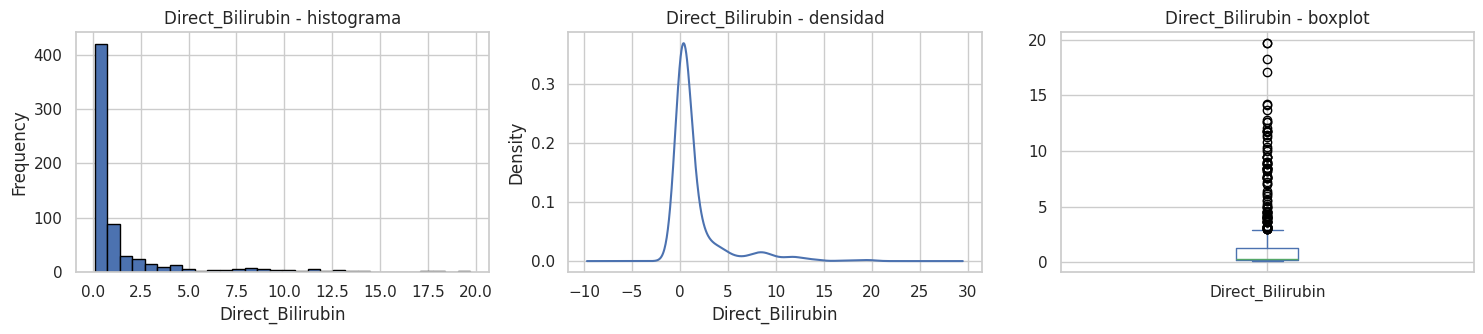

In [ ]:
# histograma, curva de densidad y diagrama de cajas
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

df["Direct_Bilirubin"].plot(
    kind="hist",
    bins=30,
    edgecolor="black",
    ax=axes[0],
    title="Direct_Bilirubin - histograma",
)
df["Direct_Bilirubin"].plot(
    kind="density", ax=axes[1], title="Direct_Bilirubin - densidad"
)
df["Direct_Bilirubin"].plot(kind="box", ax=axes[2], title="Direct_Bilirubin - boxplot")

for ax in axes[:2]:
    ax.set_xlabel("Direct_Bilirubin")
plt.tight_layout()
plt.show()

**Resultado:** valores de 0.1 a 19.7, mediana 0.3 y media 1.53, con asimetría 3.20 y curtosis 11.4. Hay 7 nulos (1.06%). El patrón es el mismo que la bilirrubina total: mayoría en valores bajos (75% por debajo de 1.3) y una cola de valores altos.

**Interpretación:** la distribución replica a la de `Total_Bilirubin` en versión atenuada, lo cual es esperable: la bilirrubina directa es una fracción de la total. El boxplot muestra numerosos puntos por encima del bigote superior; como en el caso anterior, son valores clínicamente posibles en pacientes con hígado dañado.

**Implicación:** además de la asimetría (misma recomendación de transformación logarítmica), esta variable seguramente aporta información **redundante** con la bilirrubina total; la correlación entre ambas se mide en el notebook 03.

##### Alkaline_Phosphotase

**¿Qué analizamos y por qué?** La fosfatasa alcalina, una enzima que se eleva sobre todo en enfermedades de las vías biliares y en colestasis. Hipótesis de unidades: U/L, con un rango normal aproximado de 44 a 147 en adultos.

In [ ]:
column = "Alkaline_Phosphotase"

# estadísticos descriptivos y número de valores únicos
display(df[column].describe().to_frame().T)
print(f"Valores únicos: {df[column].nunique()}")
print(
    f"Valores nulos: {df[column].isnull().sum()} ({df[column].isnull().mean() * 100:.2f}%)"
)

,count,mean,std,min,25%,50%,75%,max
Alkaline_Phosphotase,646.00,285.31,233.44,63.00,175.00,208.00,291.50,2110.00


Valores únicos: 262
Valores nulos: 17 (2.56%)


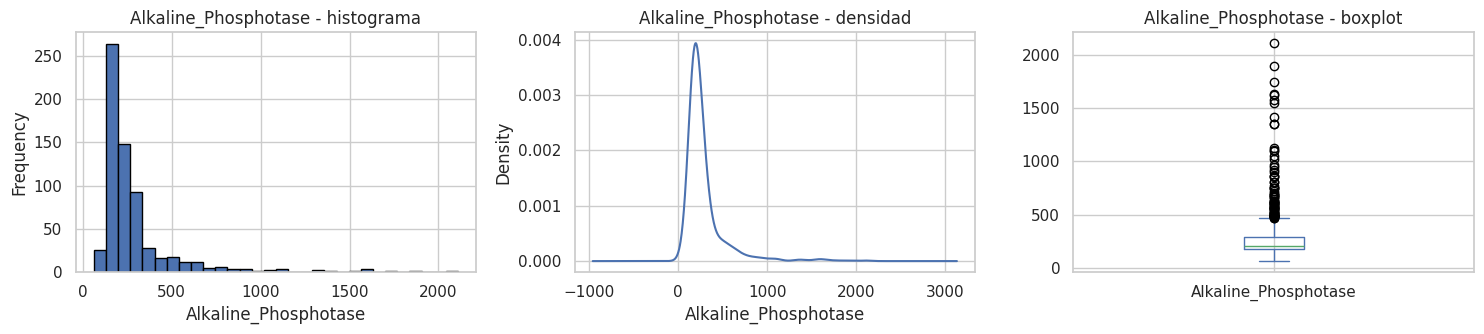

In [ ]:
# histograma, curva de densidad y diagrama de cajas
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

df["Alkaline_Phosphotase"].plot(
    kind="hist",
    bins=30,
    edgecolor="black",
    ax=axes[0],
    title="Alkaline_Phosphotase - histograma",
)
df["Alkaline_Phosphotase"].plot(
    kind="density", ax=axes[1], title="Alkaline_Phosphotase - densidad"
)
df["Alkaline_Phosphotase"].plot(
    kind="box", ax=axes[2], title="Alkaline_Phosphotase - boxplot"
)

for ax in axes[:2]:
    ax.set_xlabel("Alkaline_Phosphotase")
plt.tight_layout()
plt.show()

**Resultado:** valores de 63 a 2110, mediana 208 y media 285.3, con asimetría 3.90 y curtosis 19.3. Hay 17 nulos (2.56%), la segunda variable con más faltantes.

**Interpretación:** la mediana (208) ya está por encima del límite superior normal hipotético (147), lo que tiene sentido en un dataset de pacientes con sospecha de patología hepática: no es un problema de calidad, es el reflejo de la población estudiada. La cola derecha llega hasta 2110 (diez veces la mediana); valores así se observan en colestasis severas, por lo que también parecen reales aunque extremos.

**Implicación:** variable clínicamente plausiblemente relevante y con el mismo tratamiento recomendado que las demás enzimas: no eliminar extremos en el EDA y evaluar transformación logarítmica para el modelado.

##### Alamine_Aminotransferase

**¿Qué analizamos y por qué?** La transaminasa ALT (también llamada SGPT), una enzima muy específica del hígado: se libera a la sangre cuando hay daño en las células hepáticas. Hipótesis de unidades: U/L, rango normal aproximado de 7 a 56.

In [ ]:
column = "Alamine_Aminotransferase"

# estadísticos descriptivos y número de valores únicos
display(df[column].describe().to_frame().T)
print(f"Valores únicos: {df[column].nunique()}")
print(
    f"Valores nulos: {df[column].isnull().sum()} ({df[column].isnull().mean() * 100:.2f}%)"
)

,count,mean,std,min,25%,50%,75%,max
Alamine_Aminotransferase,644.00,80.79,185.49,10.00,23.00,35.00,60.00,2000.00


Valores únicos: 152
Valores nulos: 19 (2.87%)


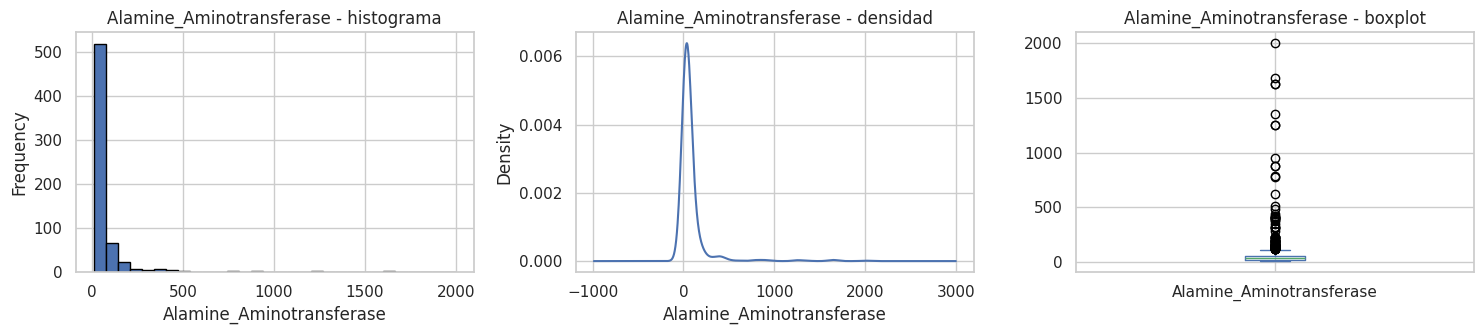

In [ ]:
# histograma, curva de densidad y diagrama de cajas
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

df["Alamine_Aminotransferase"].plot(
    kind="hist",
    bins=30,
    edgecolor="black",
    ax=axes[0],
    title="Alamine_Aminotransferase - histograma",
)
df["Alamine_Aminotransferase"].plot(
    kind="density", ax=axes[1], title="Alamine_Aminotransferase - densidad"
)
df["Alamine_Aminotransferase"].plot(
    kind="box", ax=axes[2], title="Alamine_Aminotransferase - boxplot"
)

for ax in axes[:2]:
    ax.set_xlabel("Alamine_Aminotransferase")
plt.tight_layout()
plt.show()

**Resultado:** valores de 10 a 2000, mediana 35 y media 80.8, con asimetría 6.57 y curtosis 50.2. Es la variable con más nulos: 19 (2.87%).

**Interpretación:** la mitad de los pacientes está por debajo de 35, dentro o cerca del rango normal, pero la cola derecha es muy larga: el máximo (2000) es 57 veces la mediana. Valores de miles de U/L se documentan en hepatitis agudas graves, así que son extremos **clínicamente posibles**, no errores evidentes.

**Implicación:** ALT es una de las candidatas naturales a variable predictora clave (mide daño hepático directamente). Su fuerte asimetría la hace frágil para modelos que asuman normalidad o para estadísticos basados en la media; la mediana y el IQR son mejores resúmenes, y la transformación logarítmica es una opción a evaluar.

##### Aspartate_Aminotransferase

**¿Qué analizamos y por qué?** La transaminasa AST (también llamada SGOT), otra enzima liberada ante daño celular, no solo del hígado (también aparece en corazón y músculo). Hipótesis de unidades: U/L, rango normal aproximado de 10 a 40.

In [ ]:
column = "Aspartate_Aminotransferase"

# estadísticos descriptivos y número de valores únicos
display(df[column].describe().to_frame().T)
print(f"Valores únicos: {df[column].nunique()}")
print(
    f"Valores nulos: {df[column].isnull().sum()} ({df[column].isnull().mean() * 100:.2f}%)"
)

,count,mean,std,min,25%,50%,75%,max
Aspartate_Aminotransferase,651.00,110.96,278.32,10.00,26.00,43.00,90.00,4929.00


Valores únicos: 176
Valores nulos: 12 (1.81%)


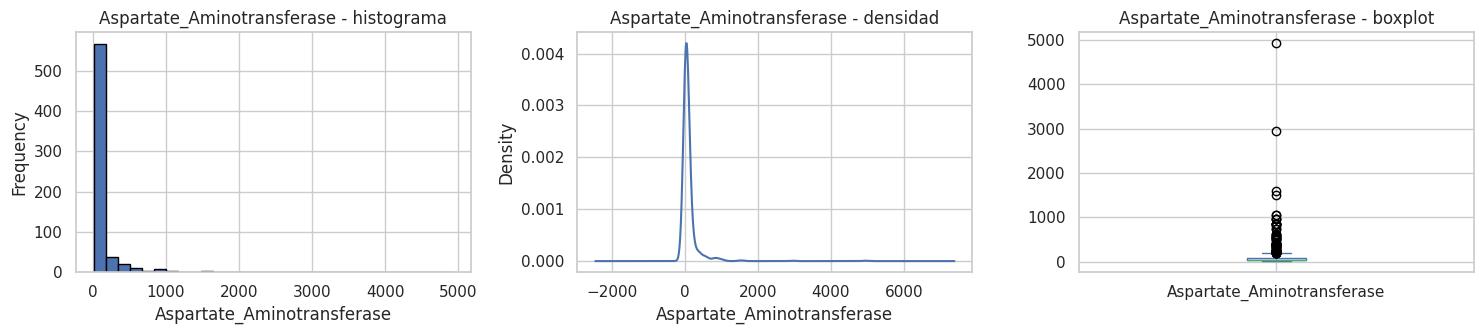

In [ ]:
# histograma, curva de densidad y diagrama de cajas
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

df["Aspartate_Aminotransferase"].plot(
    kind="hist",
    bins=30,
    edgecolor="black",
    ax=axes[0],
    title="Aspartate_Aminotransferase - histograma",
)
df["Aspartate_Aminotransferase"].plot(
    kind="density", ax=axes[1], title="Aspartate_Aminotransferase - densidad"
)
df["Aspartate_Aminotransferase"].plot(
    kind="box", ax=axes[2], title="Aspartate_Aminotransferase - boxplot"
)

for ax in axes[:2]:
    ax.set_xlabel("Aspartate_Aminotransferase")
plt.tight_layout()
plt.show()

**Resultado:** es la variable más extrema del dataset: valores de 10 a 4929, mediana 43, media 111.0, asimetría 10.61 y curtosis 156.9 (la cola más pesada de todas). Hay 12 nulos (1.81%).

**Interpretación:** el máximo (4929) supera en más de 100 veces la mediana. ¿Es ruido o es real? Es un valor **extremo**, y distinguirlo de un valor **incorrecto** es clave: las cifras de AST de varios miles se observan en la práctica clínica en hepatitis fulminantes o daño hepático isquémico, es decir, es un valor posible para un paciente muy grave. Además no hay ninguna señal de error de digitación (no hay ceros imposibles ni saltos de magnitud sin explicación). Por eso **no debemos eliminarlo automáticamente**: sería descartar justamente a los pacientes más enfermos. La decisión (conservarlo, limitarlo con una técnica como winsorización, o usar un modelo robusto) corresponde a la etapa de preparación de datos y debe evaluarse con datos no vistos.

**Implicación:** misma recomendación que las demás enzimas, con más razón aún: transformación logarítmica como candidata y descripción con estadísticos robustos.

##### Total_Protiens

**¿Qué analizamos y por qué?** Las proteínas totales del suero (la suma de albúmina y globulinas). Hipótesis de unidades: g/dL, con un rango normal aproximado de 6 a 8. Nos interesa porque la síntesis de proteínas es una función hepática.

In [ ]:
column = "Total_Protiens"

# estadísticos descriptivos y número de valores únicos
display(df[column].describe().to_frame().T)
print(f"Valores únicos: {df[column].nunique()}")
print(
    f"Valores nulos: {df[column].isnull().sum()} ({df[column].isnull().mean() * 100:.2f}%)"
)

,count,mean,std,min,25%,50%,75%,max
Total_Protiens,656.00,6.47,1.07,2.70,5.80,6.50,7.20,9.60


Valores únicos: 58
Valores nulos: 7 (1.06%)


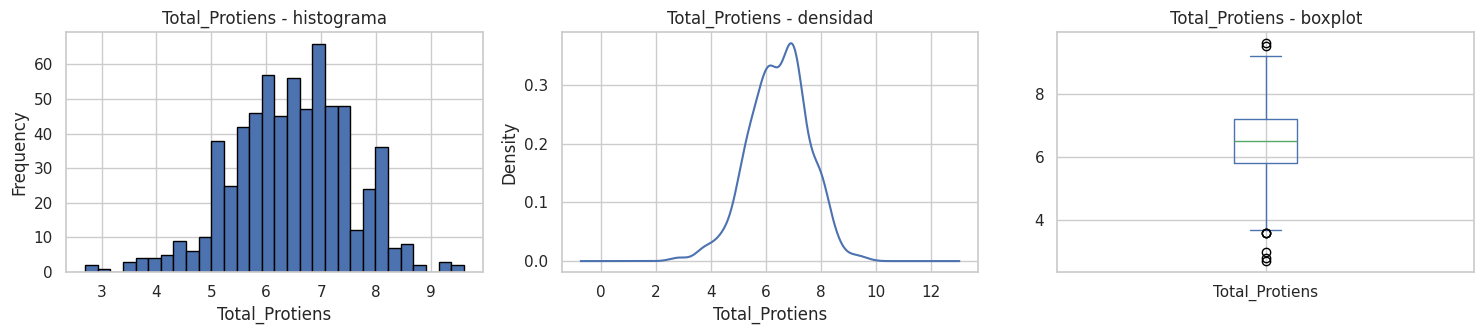

In [ ]:
# histograma, curva de densidad y diagrama de cajas
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

df["Total_Protiens"].plot(
    kind="hist",
    bins=30,
    edgecolor="black",
    ax=axes[0],
    title="Total_Protiens - histograma",
)
df["Total_Protiens"].plot(kind="density", ax=axes[1], title="Total_Protiens - densidad")
df["Total_Protiens"].plot(kind="box", ax=axes[2], title="Total_Protiens - boxplot")

for ax in axes[:2]:
    ax.set_xlabel("Total_Protiens")
plt.tight_layout()
plt.show()

**Resultado:** valores de 2.7 a 9.6, mediana 6.5 y media 6.47, con asimetría -0.24: la distribución es prácticamente simétrica y contenida. Hay 7 nulos (1.06%).

**Interpretación:** la mayoría de los pacientes está dentro del rango normal hipotético; los extremos (2.7 y 9.6) son raros pero clínicamente posibles. No hay señales de ruido ni de errores.

**Implicación:** es una variable estable y limpia. Su relación con la albúmina (que es parte de su suma) anticipa una correlación alta, con la redundancia que eso implica; se mide en el notebook 03.

##### Albumin

**¿Qué analizamos y por qué?** La albúmina, la principal proteína sintetizada por el hígado. Cuando el hígado funciona mal, la albúmina desciende, así que es un indicador de función (no de daño) complementario a las enzimas. Hipótesis de unidades: g/dL, rango normal aproximado de 3.5 a 5.0.

In [ ]:
column = "Albumin"

# estadísticos descriptivos y número de valores únicos
display(df[column].describe().to_frame().T)
print(f"Valores únicos: {df[column].nunique()}")
print(
    f"Valores nulos: {df[column].isnull().sum()} ({df[column].isnull().mean() * 100:.2f}%)"
)

,count,mean,std,min,25%,50%,75%,max
Albumin,661.00,3.12,0.79,0.90,2.60,3.10,3.70,5.50


Valores únicos: 40
Valores nulos: 2 (0.30%)


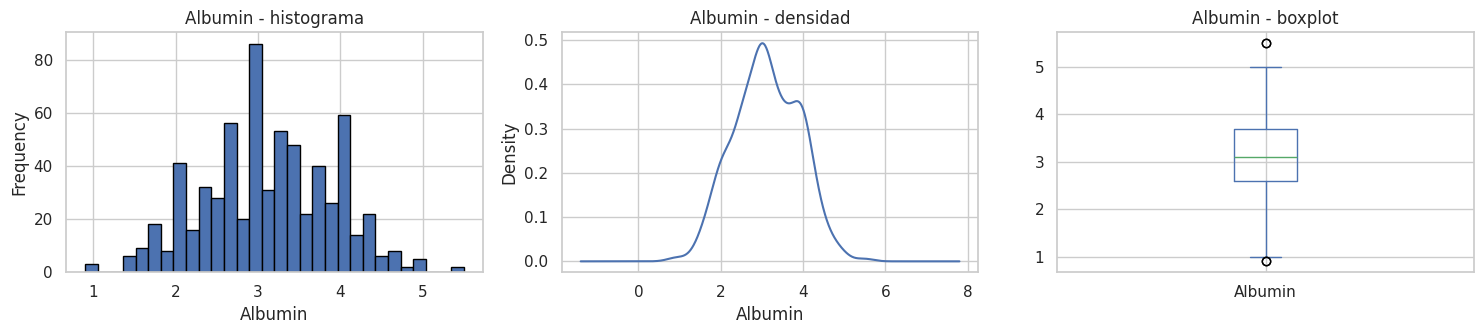

In [ ]:
# histograma, curva de densidad y diagrama de cajas
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

df["Albumin"].plot(
    kind="hist", bins=30, edgecolor="black", ax=axes[0], title="Albumin - histograma"
)
df["Albumin"].plot(kind="density", ax=axes[1], title="Albumin - densidad")
df["Albumin"].plot(kind="box", ax=axes[2], title="Albumin - boxplot")

for ax in axes[:2]:
    ax.set_xlabel("Albumin")
plt.tight_layout()
plt.show()

**Resultado:** valores de 0.9 a 5.5, mediana 3.1 y media 3.12, con asimetría -0.01 (simétrica). Solo 2 nulos (0.30%).

**Interpretación:** la mediana (3.1) está por debajo del límite inferior normal hipotético (3.5): buena parte de la población del dataset tiene albúmina baja, algo coherente con pacientes con sospecha de enfermedad hepática. El mínimo (0.9) es muy bajo y correspondería a pacientes graves; es un extremo plausible, no un error evidente.

**Implicación:** la albúmina baja puede ser un buen indicador de la clase "problemas de hígado". Al ser simétrica y estar bien comportada, probablemente no necesite transformaciones.

##### Albumin_and_Globulin_Ratio

**¿Qué analizamos y por qué?** La relación albúmina/globulina (ratio A/G). Un hígado enfermo tiende a bajar la albúmina y alterar las globulinas, lo que desplaza este cociente. Hipótesis: valores normales alrededor de 1.1 a 2.2.

In [ ]:
column = "Albumin_and_Globulin_Ratio"

# estadísticos descriptivos y número de valores únicos
display(df[column].describe().to_frame().T)
print(f"Valores únicos: {df[column].nunique()}")
print(
    f"Valores nulos: {df[column].isnull().sum()} ({df[column].isnull().mean() * 100:.2f}%)"
)

,count,mean,std,min,25%,50%,75%,max
Albumin_and_Globulin_Ratio,659.00,0.94,0.32,0.30,0.70,0.93,1.10,2.80


Valores únicos: 69
Valores nulos: 4 (0.60%)


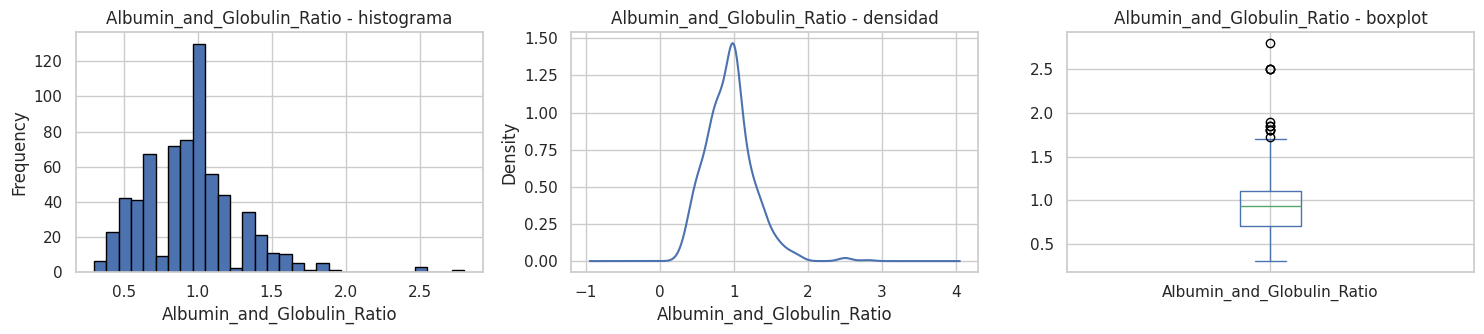

In [ ]:
# histograma, curva de densidad y diagrama de cajas
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

df["Albumin_and_Globulin_Ratio"].plot(
    kind="hist",
    bins=30,
    edgecolor="black",
    ax=axes[0],
    title="Albumin_and_Globulin_Ratio - histograma",
)
df["Albumin_and_Globulin_Ratio"].plot(
    kind="density", ax=axes[1], title="Albumin_and_Globulin_Ratio - densidad"
)
df["Albumin_and_Globulin_Ratio"].plot(
    kind="box", ax=axes[2], title="Albumin_and_Globulin_Ratio - boxplot"
)

for ax in axes[:2]:
    ax.set_xlabel("Albumin_and_Globulin_Ratio")
plt.tight_layout()
plt.show()

**Resultado:** valores de 0.3 a 2.8, mediana 0.93 y media 0.94, con asimetría 1.03 (moderada). Hay 4 nulos (0.60%).

**Interpretación:** la mediana está por debajo de 1, es decir, la mayoría de los pacientes tiene más globulinas que albúmina relativamente, un patrón compatible con patología hepática crónica. La asimetría es moderada y los extremos (0.3 y 2.8) son valores posibles.

**Implicación:** variable limpia y potencialmente útil. Al construirse con la albúmina, es probable que correlacione con ella (se verifica en el notebook 03), lo que de nuevo plantea la pregunta de redundancia.

#### Variables categóricas

Nos queda el análisis univariable de la variable categórica `Gender` (el target `Dataset` ya se analizó al principio de la sección). Para las categóricas estudiamos las categorías existentes, sus frecuencias absolutas y relativas, la moda y la posible presencia de categorías inconsistentes.

In [ ]:
# lista de las columnas categóricas
categorical_columns = list(df.select_dtypes(include=["category"]).columns)
categorical_columns

['Gender', 'Dataset']

##### Gender

**¿Qué analizamos y por qué?** El género del paciente. Queremos ver cómo se reparte entre hombres y mujeres, porque un desbalance fuerte de esta variable podría sesgar las conclusiones y las predicciones de un futuro modelo.

In [ ]:
column = "Gender"

print("Categorías:", df[column].unique().tolist())
print(
    f"Valores nulos: {df[column].isnull().sum()} ({df[column].isnull().mean() * 100:.2f}%)"
)

pd.DataFrame(
    {
        "cantidad": df[column].value_counts(),
        "porcentaje": (df[column].value_counts(normalize=True) * 100).round(2),
    }
)

Categorías: ['Female', 'Male', nan]
Valores nulos: 8 (1.21%)


,cantidad,porcentaje
Gender,,
Male,499,76.18
Female,156,23.82


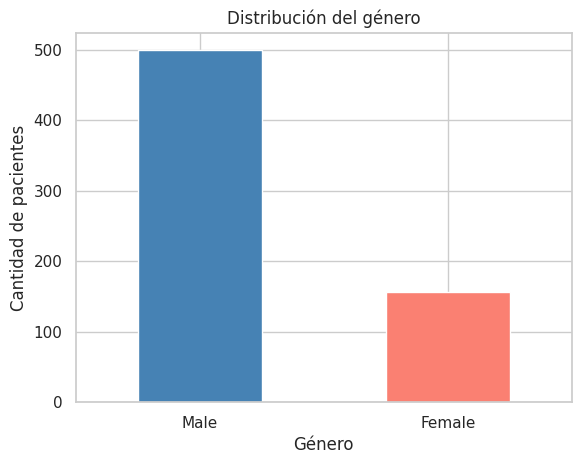

In [ ]:
df[column].value_counts().plot(
    kind="bar", color=["steelblue", "salmon"], title="Distribución del género"
)
plt.xlabel("Género")
plt.ylabel("Cantidad de pacientes")
plt.xticks(rotation=0)
plt.show()

**Resultado:** hay 499 hombres (76.2% de los 655 pacientes con dato) y 156 mujeres (23.8%), además de 8 valores nulos (1.21%). La moda es claramente `Male`. Solo existen las dos categorías esperadas: no hay inconsistencias de escritura (por ejemplo "male" con minúsculas o "M") gracias al trabajo de tipado de la etapa anterior.

**Interpretación:** los hombres predominan con una proporción de más de 3 a 1. Esto puede reflejar diferencias reales en la prevalencia o en la atención sanitaria de la población de origen, o simplemente cómo se recolectaron los datos; con la información disponible no podemos distinguir entre esas explicaciones.

**Implicación para el proyecto:** el modelo futuro tendrá muchas menos ejemplos de mujeres, por lo que sus predicciones podrían ser menos confiables para ese grupo. Además, el análisis bivariable (notebook 03) tendrá que comprobar si la relación entre las pruebas clínicas y el diagnóstico es distinta por género; de ser así, el desbalance actual sería un problema adicional.

### Conclusiones del análisis univariable

**¿Qué aprendimos sobre nuestras variables?**

- **El target** es `Dataset`, con dos clases almacenadas como texto: `1` (problemas de hígado, 460 pacientes, 71%) y `2` (sin problemas, 188, 29%), más 15 registros sin etiqueta. Hay un desbalance moderado que condicionará las métricas y las técnicas de entrenamiento del futuro modelo.
- **Variables simétricas y estables:** `Age`, `Albumin`, `Total_Protiens` y `Albumin_and_Globulin_Ratio` tienen distribuciones equilibradas, medias cercanas a las medianas y valores extremos escasos y plausibles.
- **Variables fuertemente asimétricas:** las cinco pruebas hepáticas (`Total_Bilirubin`, `Direct_Bilirubin`, `Alkaline_Phosphotase`, `Alamine_Aminotransferase`, `Aspartate_Aminotransferase`) tienen colas derechas muy largas. Sus máximos (75, 19.7, 2110, 2000 y 4929 respectivamente) son valores extremos clínicamente posibles en pacientes graves, no errores evidentes: no deben eliminarse en esta etapa.
- **Inconsistencia entre variables:** 3 filas tienen bilirrubina directa mayor que la total, algo fisiológicamente imposible y con toda probabilidad errores de captura (dos de ellas con diferencias flagrantes: 1.8/9.0 y 1.5/7.0). Quedan identificadas para la etapa de preparación.
- **Nulos:** 98 celdas (1.34%), repartidas en las 11 columnas. Destacan los 15 nulos del target, que no servirán para entrenamiento supervisado.
- **Duplicados:** 60 filas duplicadas (9.0%), en 51 grupos. Sin identificador de paciente no se puede saber si son repeticiones del mismo paciente o coincidencias entre pacientes; la decisión queda para la etapa de preparación.
- **Género:** 76% hombres y 24% mujeres, con 8 nulos. Este desbalance debe vigilarse para no sesgar las conclusiones.
- **Utilidad esperada:** no hay identificadores ni variables inútiles. Todas las pruebas clínicas tienen sentido como predictoras; las que miden daño hepático directo (transaminasas y bilirrubinas) y función (albúmina) son las candidatas naturales más fuertes. Ninguna variable parece filtrar información del futuro.

## 📊 Análisis de resultados y conclusiones

El dataset es una tabla clínica compacta (663 registros, 11 variables) con calidad de datos razonable: nulos escasos, duplicados moderados y tipos correctos. El trabajo del EDA consistirá en entender si las diferencias entre pacientes enfermos y sanos son visibles en las pruebas hepáticas, y con cuánta separación. Las preguntas abiertas que pasan al notebook 03 son: ¿qué variables separan mejor las clases del target?, ¿cuánta redundancia hay entre ellas? y ¿el patrón es distinto entre hombres y mujeres?

## 💡 Propuestas e ideas

- Estudiar en el notebook 03 la relación de cada variable numérica con el target, priorizando transaminasas, bilirrubinas y albúmina.
- Cuantificar la redundancia entre variables con la matriz de correlación (ya anticipada por el perfilado: bilirrubinas entre sí, albúmina con proteínas totales y con el ratio A/G, ALT con AST).
- Documentar en el notebook 04 las reglas de validación, las transformaciones candidatas (logarítmica para las pruebas hepáticas) y las decisiones pendientes para la etapa de preparación de datos.
- Marcar como pendiente de decisión: tratamiento de los 15 registros sin etiqueta, los 60 duplicados y los 8 nulos de género.

## 📖 Referencias

- Interpretación clínica de las pruebas de función hepática (StatPearls, NCBI): <https://www.ncbi.nlm.nih.gov/books/NBK482489/>
- Documentación de pandas: <https://pandas.pydata.org/docs/>